## 1. Importy i ładowanie modelu

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import traitlets
import ipywidgets.widgets as widgets
from IPython.display import display

tf.config.set_visible_devices([], 'GPU')
print("Visible devices:", tf.config.get_visible_devices())
MODEL_PATH = '100epochs.keras'

model = tf.keras.models.load_model(MODEL_PATH)
print('Model załadowany:', MODEL_PATH)
model.summary()

2026-05-13 12:00:12.067619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-13 12:00:12.089459: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-13 12:00:12.089502: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-13 12:00:12.103470: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-13 12:00:12.738989: W tensorflow/compiler/tf

Visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Model załadowany: 100epochs.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 112, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 112, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 112, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 112, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 113, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 56, 112,   │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 56, 112,   │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 56, 112,   │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 56, 112,   │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 56, 112,   │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 56, 112,   │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 56, 112,   │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 56, 112,   │        512 │ block1a_se_excit

 Total params: 12,072,355 (46.05 MB)

 Trainable params: 4,010,110 (15.30 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 8,020,222 (30.59 MB)

## 2. Preprocessing — identyczny jak podczas treningu

In [2]:
def crop_image(img):
    imsize = img.shape
    return img[imsize[0] // 2:, :]


def preprocess(bgr_frame):
    img = crop_image(bgr_frame)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)
    return img

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import os

DATASET_DIR = 'data'
LABELS_CSV  = 'inputs.csv'

df = pd.read_csv(LABELS_CSV)
df = df[df['uuid'].apply(lambda u: os.path.exists(os.path.join(DATASET_DIR, u + '.jpeg')))].reset_index(drop=True)[:50]
print(f'Załadowano {len(df)} rekordów z istniejącymi plikami.')
df.head()

Załadowano 50 rekordów z istniejącymi plikami.


,uuid,timestamp,left_wheel,right_wheel
0,6124b714-494a-11f1-83c5-16f63a1aa8c9,2026-05-06T05:52:03.146658,0.000004,0.000002
1,61276e46-494a-11f1-83c5-16f63a1aa8c9,2026-05-06T05:52:03.158243,0.000004,0.000002
2,612ac8de-494a-11f1-83c5-16f63a1aa8c9,2026-05-06T05:52:03.180276,0.000004,0.000002
3,612d64e0-494a-11f1-83c5-16f63a1aa8c9,2026-05-06T05:52:03.197303,0.000004,0.000002
4,612fde82-494a-11f1-83c5-16f63a1aa8c9,2026-05-06T05:52:03.213745,0.000004,0.000002


In [4]:
def predict_from_file(img_path):
    img = plt.imread(img_path)
    img = crop_image(img)
    img = img.astype(np.float32) / 255.0
    inp = np.expand_dims(img, axis=0)
    left, right = model(inp, training=False).numpy()[0]
    return float(left), float(right), img


## 8. Testowanie modelu (offline)

Sekcja do weryfikacji modelu **bez uruchamiania robota** — na zapisanych zdjęciach z datasetu.
Można uruchomić niezależnie od powyższych komórek (nie wymaga kamery ani silników).

> Upewnij się że komórki 1 i 2 (model + preprocessing) zostały wcześniej uruchomione.

In [5]:
import time

#make sure tf runs on cpu
tf.config.set_visible_devices([], 'GPU')

# Number of runs (first few are slower due to TF warmup, so we discard them)
N_WARMUP = 5
N_RUNS   = 50

# Use a real camera frame if available, otherwise a random array
try:
    test_frame = camera.value  # BGR 224×224
except:
    test_frame = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)

inp = preprocess(test_frame)

# Warmup
for _ in range(N_WARMUP):
    _ = model(inp, training=False)

# Timed runs
times = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    _ = model(inp, training=False)
    times.append(time.perf_counter() - t0)

times = np.array(times) * 1000  # convert to ms

print(f"Inference time over {N_RUNS} runs:")
print(f"  Mean   : {times.mean():.2f} ms")
print(f"  Median : {np.median(times):.2f} ms")
print(f"  Std    : {times.std():.2f} ms")
print(f"  Min    : {times.min():.2f} ms")
print(f"  Max    : {times.max():.2f} ms")
print(f"  Est. FPS: {1000 / times.mean():.1f}")

Inference time over 50 runs:
  Mean   : 180.13 ms
  Median : 178.43 ms
  Std    : 12.79 ms
  Min    : 161.34 ms
  Max    : 236.75 ms
  Est. FPS: 5.6


Próbek ocenionych : 50
MAE  lewy : 0.0680   prawy : 0.0694
MSE  lewy : 0.0090   prawy : 0.0097


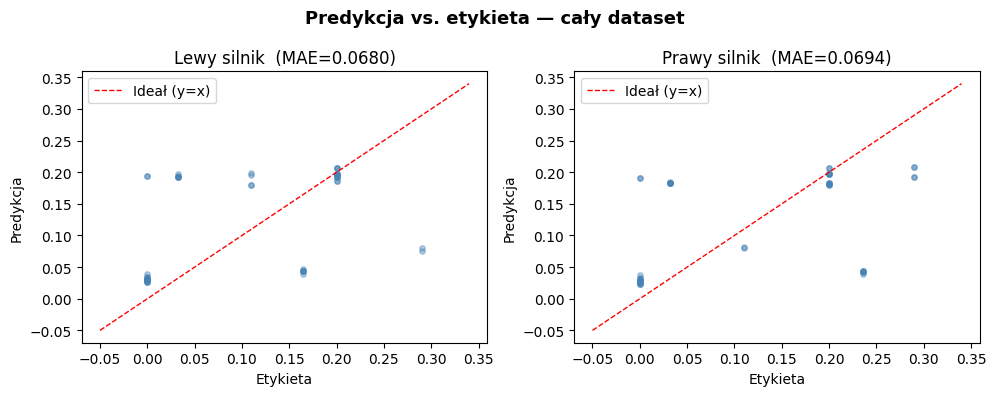

In [6]:
true_lefts, true_rights = [], []
pred_lefts, pred_rights = [], []

for _, row in df.iterrows():
    img_path = os.path.join(DATASET_DIR, row['uuid'] + '.jpeg')
    pl, pr, _ = predict_from_file(img_path)
    true_lefts.append(row['left_wheel'])
    true_rights.append(row['right_wheel'])
    pred_lefts.append(pl)
    pred_rights.append(pr)

true_lefts  = np.array(true_lefts)
true_rights = np.array(true_rights)
pred_lefts  = np.array(pred_lefts)
pred_rights = np.array(pred_rights)

mae_l = np.mean(np.abs(true_lefts  - pred_lefts))
mae_r = np.mean(np.abs(true_rights - pred_rights))
mse_l = np.mean((true_lefts  - pred_lefts)  ** 2)
mse_r = np.mean((true_rights - pred_rights) ** 2)

print(f'Próbek ocenionych : {len(true_lefts)}')
print(f'MAE  lewy : {mae_l:.4f}   prawy : {mae_r:.4f}')
print(f'MSE  lewy : {mse_l:.4f}   prawy : {mse_r:.4f}')

# Scatter: predykcja vs. etykieta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Predykcja vs. etykieta — cały dataset', fontsize=13, fontweight='bold')

for ax, true, pred, title in [
    (ax1, true_lefts,  pred_lefts,  'Lewy silnik'),
    (ax2, true_rights, pred_rights, 'Prawy silnik'),
]:
    ax.scatter(true, pred, alpha=0.4, s=15, color='steelblue')
    lims = [min(true.min(), pred.min()) - 0.05, max(true.max(), pred.max()) + 0.05]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Ideał (y=x)')
    ax.set_xlabel('Etykieta')
    ax.set_ylabel('Predykcja')
    ax.set_title(f'{title}  (MAE={np.mean(np.abs(true - pred)):.4f})')
    ax.legend()

plt.tight_layout()
plt.show()